<a href="https://colab.research.google.com/github/chinmay227/indian-market-internals/blob/main/notebooks/02_calculate_relative_returns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calculate Relative Returns

This notebook tests whether Indian stocks that outperformed Nifty over the previous 6 months continued to outperform over the next 3 months.

The first version uses a starter universe of large Indian stocks. Later versions will expand to Nifty 100, Nifty 200, or Nifty 500.

In [1]:
!pip -q install yfinance pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [3]:
START_DATE = "2018-01-01"

INDEX_TICKER = "^NSEI"  # Nifty 50 index on Yahoo Finance

STOCK_TICKERS = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "INFY.NS",
    "HINDUNILVR.NS",
    "ITC.NS",
    "LT.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "AXISBANK.NS",
    "KOTAKBANK.NS",
    "BAJFINANCE.NS",
    "ASIANPAINT.NS",
    "MARUTI.NS",
    "HCLTECH.NS",
    "SUNPHARMA.NS",
    "TMCV.NS",
    "TITAN.NS",
    "ULTRACEMCO.NS",
    "NESTLEIND.NS",
    "POWERGRID.NS",
    "NTPC.NS",
    "ONGC.NS",
    "COALINDIA.NS",
]

TICKERS = [INDEX_TICKER] + STOCK_TICKERS

LOOKBACK_MONTHS = 6
FORWARD_MONTHS = 3

print("Total tickers:", len(TICKERS))

Total tickers: 26


In [4]:
raw = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    auto_adjust=True,
    group_by="ticker",
    multi_level_index=True,
    progress=False,
    threads=True
)

raw.head()

Ticker         SBIN.NS                                               KOTAKBANK.NS                                      \
Price             Open        High         Low       Close    Volume         Open        High         Low       Close   
Date                                                                                                                    
2018-01-01  281.521356  283.470066  277.623910  278.349030  12182400   200.969769  201.039292  197.980601  198.606247   
2018-01-02  280.071115  280.071115  273.137321  274.859436  14797364   198.814797  199.807878  197.126562  199.251755   
2018-01-03  276.717499  277.759857  273.862411  274.496887  13857373   199.132573  199.986623  198.238791  198.636032   
2018-01-04  275.992464  281.158837  274.768847  279.617981  24517099   198.814783  199.192158  197.841568  198.695618   
2018-01-05  282.246392  282.246392  276.989405  277.669189  14580575   199.112700  199.946884  197.940872  199.221939   

Ticker                 POWERGRID.NS                                           SUNPHARMA.NS                          \
Price           Volume         Open       High        Low      Close   Volume         Open        High         Low   
Date                                                                                                                 
2018-01-01   6587075.0    72.847326  73.835460  72.847326  73.268196  6388017   527.927875  540.768138  527.696935   
2018-01-02   5361035.0    73.652462  73.853746  72.938809  73.469475  4383705   533.008649  537.627441  523.955827   
2018-01-03   4420105.0    73.743963  74.091637  73.414582  73.798859  8187397   531.160923  534.809779  523.770858   
2018-01-04   3919750.0    73.926944  74.238019  73.194995  73.323082  4204055   528.389779  539.428702  517.397032   
2018-01-05  10737010.0    73.670763  73.945244  73.414578  73.652466  4923559   540.398673  542.569483  531.438205   

Ticker                          ASIANPAINT.NS                                                    ...  HCLTECH.NS  \
Price            Close   Volume          Open         High          Low        Close     Volume  ...        Open   
Date                                                                                             ...               
2018-01-01  530.283447  5314142   1080.939240  1082.798121  1057.796150  1062.954590   591349.0  ...  341.343923   
2018-01-02  528.528442  3839130   1065.138968  1068.856731  1054.032198  1062.118286   516171.0  ...  336.697996   
2018-01-03  525.664551  2182632   1067.927130  1067.927130  1055.193840  1061.328125   593809.0  ...  342.879813   
2018-01-04  536.888367  6246746   1067.927300  1094.881079  1065.046057  1089.350952   729965.0  ...  344.031657   
2018-01-05  534.625183  4600683   1094.881062  1107.893231  1085.075418  1101.619507  1151320.0  ...  341.055931   

Ticker                                                  NESTLEIND.NS                                               \
Price             High         Low       Close   Volume         Open        High         Low       Close   Volume   
Date                                                                                                                
2018-01-01  341.996666  336.333198  337.389099  1286288   354.138822  354.210535  350.938118  352.489166   132120   
2018-01-02  343.647734  336.678779  342.803009  1906518   352.121615  355.172137  351.583677  352.504883  1312260   
2018-01-03  348.562475  342.879813  344.530853  2583906   354.138810  355.707779  351.904156  352.350189   558960   
2018-01-04  345.356337  339.059319  342.918152  1193460   352.569925  354.237502  351.404415  352.760437   558040   
2018-01-05  346.719399  338.771341  345.586700  1492292   351.731570  353.421583  351.493970  352.200012   199400   

Ticker     ULTRACEMCO.NS                                                  AXISBANK.NS                          \
Price               Open         High          Low        Close    Volume        Open        High         L

In [5]:
downloaded_tickers = sorted(set(raw.columns.get_level_values(0)))
missing_tickers = [ticker for ticker in TICKERS if ticker not in downloaded_tickers]

print("Downloaded tickers:", len(downloaded_tickers))
print("Missing tickers:", missing_tickers)

Downloaded tickers: 26
Missing tickers: []


In [6]:
close_prices = pd.DataFrame()

for ticker in TICKERS:
    if ticker in downloaded_tickers:
        close_prices[ticker] = raw[ticker]["Close"]

close_prices.index = pd.to_datetime(close_prices.index)
close_prices.index.name = "Date"

close_prices = close_prices.rename(columns={INDEX_TICKER: "NIFTY"})
close_prices = close_prices.dropna(how="all")

close_prices.tail()

,NIFTY,RELIANCE.NS,TCS.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,HINDUNILVR.NS,ITC.NS,LT.NS,SBIN.NS,BHARTIARTL.NS,AXISBANK.NS,KOTAKBANK.NS,BAJFINANCE.NS,ASIANPAINT.NS,MARUTI.NS,HCLTECH.NS,SUNPHARMA.NS,TMCV.NS,TITAN.NS,ULTRACEMCO.NS,NESTLEIND.NS,POWERGRID.NS,NTPC.NS,ONGC.NS,COALINDIA.NS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-10,24583.800781,1327.300049,2425.699951,731.0,1431.800049,1183.000000,2087.199951,282.649994,4080.000000,1071.000000,1943.000000,1247.300049,393.500000,1102.199951,2750.000000,14097.0,1357.199951,1944.400024,450.200012,5090.000000,12038.0,1528.599976,270.100006,340.450012,239.839996,411.000000
2026-08-11,24471.699219,1323.900024,2445.699951,729.0,1429.599976,1190.699951,2064.899902,279.000000,4037.399902,1066.000000,1915.199951,1229.800049,392.899994,1093.300049,2735.500000,13990.0,1365.400024,1942.000000,450.049988,5128.000000,11780.0,1493.199951,267.950012,338.450012,239.449997,412.600006
2026-08-12,24435.949219,1329.000000,2349.699951,729.0,1431.699951,1176.099976,2063.000000,276.149994,4020.000000,1082.000000,1945.000000,1230.000000,390.500000,1094.199951,2740.000000,13875.0,1365.400024,1944.000000,457.049988,5099.000000,11891.0,1507.000000,269.450012,339.450012,239.050003,409.299988
2026-08-13,24395.849609,1317.000000,2375.000000,725.0,1406.800049,1175.000000,2092.000000,278.500000,4070.699951,1083.000000,1939.099976,1221.800049,392.399994,1090.800049,2755.500000,13905.0,1370.000000,1932.000000,474.799988,5063.700195,11706.0,1506.900024,266.600006,344.250000,239.899994,410.500000
2026-08-14,24366.000000,1310.000000,2361.000000,727.0,1417.000000,1169.199951,2077.000000,278.200012,4057.000000,1067.699951,1992.099976,1217.400024,391.149994,1087.000000,2696.300049,13834.0,1360.000000,1930.000000,474.299988,5056.200195,11619.0,1499.099976,266.049988,340.000000,236.399994,407.100006


In [7]:
monthly_prices = close_prices.resample("M").last()

monthly_prices.tail()

/tmp/ipykernel_853/489150236.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = close_prices.resample("M").last()


,NIFTY,RELIANCE.NS,TCS.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,HINDUNILVR.NS,ITC.NS,LT.NS,SBIN.NS,BHARTIARTL.NS,AXISBANK.NS,KOTAKBANK.NS,BAJFINANCE.NS,ASIANPAINT.NS,MARUTI.NS,HCLTECH.NS,SUNPHARMA.NS,TMCV.NS,TITAN.NS,ULTRACEMCO.NS,NESTLEIND.NS,POWERGRID.NS,NTPC.NS,ONGC.NS,COALINDIA.NS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-30,23997.550781,1424.215088,2427.495117,759.144165,1252.838013,1156.768311,2228.235352,306.548584,3975.173096,1049.532104,1863.349365,1267.322632,382.639374,931.275269,2423.473877,13181.616211,1186.981812,1803.573242,405.324585,4370.857910,11354.241211,1451.621948,318.350006,399.149994,299.549988,475.102997
2026-05-31,23547.750000,1315.119385,2246.582031,732.435913,1245.896484,1136.310913,2131.816162,286.899994,4076.500000,964.400024,1806.267700,1285.608521,383.537842,902.700928,2648.620605,12996.475586,1171.836426,1794.496948,375.263916,4061.572754,11252.322266,1414.699463,290.549988,386.899994,265.399994,451.863434
2026-06-30,23865.750000,1293.900024,2020.422119,797.950012,1363.703247,1000.400024,2118.199951,286.950012,4143.399902,1026.900024,1828.981812,1344.662964,391.573975,1004.750000,2635.699951,13974.652344,1060.968384,1857.631470,422.950012,4389.596191,11027.902344,1398.477417,286.299988,356.649994,234.899994,433.261932
2026-07-31,24383.599609,1307.800049,2365.600098,748.150024,1423.400024,1130.099976,2101.300049,281.000000,3938.899902,1027.400024,1972.000000,1229.500000,389.399994,1141.199951,2746.199951,14046.925781,1346.900024,1990.500000,436.799988,4875.200195,11847.000000,1509.599976,284.250000,347.250000,242.529999,414.149994
2026-08-31,24366.000000,1310.000000,2361.000000,727.000000,1417.000000,1169.199951,2077.000000,278.200012,4057.000000,1067.699951,1992.099976,1217.400024,391.149994,1087.000000,2696.300049,13834.000000,1360.000000,1930.000000,474.299988,5056.200195,11619.000000,1499.099976,266.049988,340.000000,236.399994,407.100006


In [8]:
missing_summary = pd.DataFrame({
    "first_valid_date": monthly_prices.apply(lambda s: s.first_valid_index()),
    "last_valid_date": monthly_prices.apply(lambda s: s.last_valid_index()),
    "missing_pct": monthly_prices.isna().mean().round(4)
})

missing_summary.sort_values("missing_pct", ascending=False).head(10)

,first_valid_date,last_valid_date,missing_pct
TMCV.NS,2025-11-30,2026-08-31,0.9038
NIFTY,2018-01-31,2026-08-31,0.0000
TCS.NS,2018-01-31,2026-08-31,0.0000
HDFCBANK.NS,2018-01-31,2026-08-31,0.0000
ICICIBANK.NS,2018-01-31,2026-08-31,0.0000
INFY.NS,2018-01-31,2026-08-31,0.0000
HINDUNILVR.NS,2018-01-31,2026-08-31,0.0000
ITC.NS,2018-01-31,2026-08-31,0.0000
LT.NS,2018-01-31,2026-08-31,0.0000
RELIANCE.NS,2018-01-31,2026-08-31,0.0000


In [9]:
past_returns = monthly_prices.pct_change(LOOKBACK_MONTHS)

future_returns = monthly_prices.shift(-FORWARD_MONTHS) / monthly_prices - 1

past_returns.tail(), future_returns.tail()

(               NIFTY  RELIANCE.NS    TCS.NS  HDFCBANK.NS  ICICIBANK.NS   INFY.NS  HINDUNILVR.NS    ITC.NS     LT.NS  \
 Date                                                                                                                  
 2026-04-30 -0.067045    -0.037406 -0.176301    -0.218373     -0.060879 -0.202726      -0.079864 -0.235162 -0.004193   
 2026-05-31 -0.101332    -0.157129 -0.257004    -0.261066     -0.095334 -0.255881      -0.126936 -0.255677  0.011479   
 2026-06-30 -0.086639    -0.172260 -0.346118    -0.181651      0.024052 -0.367310      -0.076063 -0.253238  0.024579   
 2026-07-31 -0.037007    -0.058444 -0.228265    -0.181572      0.059336 -0.296432      -0.105489 -0.085194  0.011462   
 2026-08-31 -0.032275    -0.055846 -0.087687    -0.167531      0.036294 -0.081224      -0.102636 -0.088715 -0.042464   
 
              SBIN.NS  BHARTIARTL.NS  AXISBANK.NS  KOTAKBANK.NS  BAJFINANCE.NS  ASIANPAINT.NS  MARUTI.NS  HCLTECH.NS  \
 Date                                 

In [10]:
stock_cols = [col for col in monthly_prices.columns if col != "NIFTY"]

records = []

for date in monthly_prices.index:
    for ticker in stock_cols:
        past_stock_return = past_returns.loc[date, ticker]
        past_nifty_return = past_returns.loc[date, "NIFTY"]
        future_stock_return = future_returns.loc[date, ticker]
        future_nifty_return = future_returns.loc[date, "NIFTY"]

        if pd.notna(past_stock_return) and pd.notna(past_nifty_return) and pd.notna(future_stock_return) and pd.notna(future_nifty_return):
            past_relative_return = past_stock_return - past_nifty_return
            future_relative_return = future_stock_return - future_nifty_return

            records.append({
                "date": date,
                "ticker": ticker,
                "past_stock_return": past_stock_return,
                "past_nifty_return": past_nifty_return,
                "past_relative_return": past_relative_return,
                "future_stock_return": future_stock_return,
                "future_nifty_return": future_nifty_return,
                "future_relative_return": future_relative_return,
                "past_group": "Past Outperformer" if past_relative_return > 0 else "Past Underperformer"
            })

analysis_df = pd.DataFrame(records)

analysis_df.head()

,date,ticker,past_stock_return,past_nifty_return,past_relative_return,future_stock_return,future_nifty_return,future_relative_return,past_group
0,2018-07-31,RELIANCE.NS,0.241993,0.029816,0.212177,-0.105185,-0.085405,-0.019781,Past Outperformer
1,2018-07-31,TCS.NS,0.259683,0.029816,0.229867,0.001048,-0.085405,0.086452,Past Outperformer
2,2018-07-31,HDFCBANK.NS,0.093594,0.029816,0.063778,-0.122849,-0.085405,-0.037444,Past Outperformer
3,2018-07-31,ICICIBANK.NS,-0.137980,0.029816,-0.167796,0.172017,-0.085405,0.257422,Past Underperformer
4,2018-07-31,INFY.NS,0.215876,0.029816,0.186060,0.016592,-0.085405,0.101997,Past Outperformer


In [11]:
analysis_df.shape

(2281, 9)

In [12]:
binary_summary = (
    analysis_df
    .groupby("past_group")
    .agg(
        observations=("ticker", "count"),
        avg_past_relative_return=("past_relative_return", "mean"),
        avg_future_relative_return=("future_relative_return", "mean"),
        median_future_relative_return=("future_relative_return", "median"),
        win_rate_vs_nifty=("future_relative_return", lambda x: (x > 0).mean())
    )
    .reset_index()
)

binary_summary

,past_group,observations,avg_past_relative_return,avg_future_relative_return,median_future_relative_return,win_rate_vs_nifty
0,Past Outperformer,1241,0.137504,0.009255,0.003971,0.515713
1,Past Underperformer,1040,-0.104589,0.016244,0.005421,0.525000


In [13]:
analysis_df["past_relative_rank"] = (
    analysis_df
    .groupby("date")["past_relative_return"]
    .rank(pct=True)
)

def assign_bucket(rank):
    if rank >= 0.80:
        return "Top 20% Past Winners"
    elif rank <= 0.20:
        return "Bottom 20% Past Losers"
    else:
        return "Middle 60%"

analysis_df["past_bucket"] = analysis_df["past_relative_rank"].apply(assign_bucket)

bucket_summary = (
    analysis_df
    .groupby("past_bucket")
    .agg(
        observations=("ticker", "count"),
        avg_past_relative_return=("past_relative_return", "mean"),
        avg_future_relative_return=("future_relative_return", "mean"),
        median_future_relative_return=("future_relative_return", "median"),
        win_rate_vs_nifty=("future_relative_return", lambda x: (x > 0).mean())
    )
    .reset_index()
    .sort_values("avg_future_relative_return", ascending=False)
)

bucket_summary

,past_bucket,observations,avg_past_relative_return,avg_future_relative_return,median_future_relative_return,win_rate_vs_nifty
1,Middle 60%,1424,0.008047,0.013381,0.003823,0.516152
2,Top 20% Past Winners,476,0.244455,0.011513,0.011332,0.542017
0,Bottom 20% Past Losers,381,-0.173095,0.010092,0.001924,0.506562


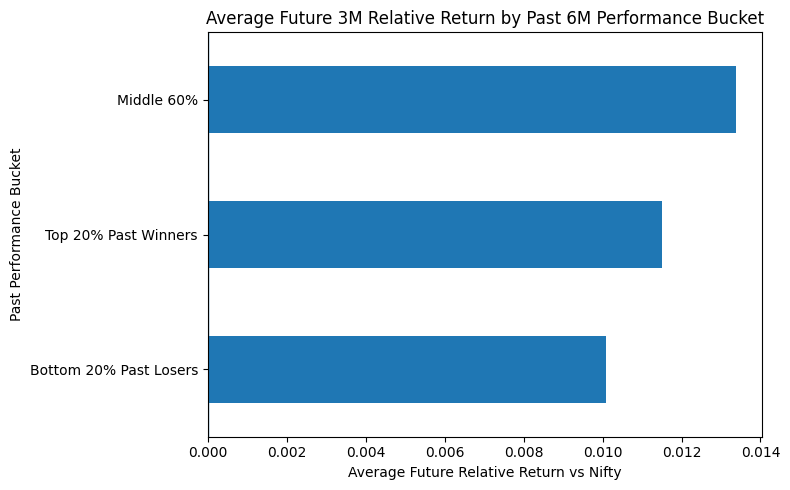

In [14]:
chart_data = bucket_summary.set_index("past_bucket")["avg_future_relative_return"].sort_values()

plt.figure(figsize=(8, 5))
chart_data.plot(kind="barh")
plt.axvline(0, linewidth=1)
plt.title("Average Future 3M Relative Return by Past 6M Performance Bucket")
plt.xlabel("Average Future Relative Return vs Nifty")
plt.ylabel("Past Performance Bucket")
plt.tight_layout()
plt.show()

In [15]:
output_dir = Path("/content/indian-market-internals-output")
output_dir.mkdir(parents=True, exist_ok=True)

analysis_df.to_csv(output_dir / "relative_returns_starter_universe.csv", index=False)
binary_summary.to_csv(output_dir / "binary_momentum_summary.csv", index=False)
bucket_summary.to_csv(output_dir / "bucket_momentum_summary.csv", index=False)

print("Saved files:")
for file in output_dir.iterdir():
    print(file)

Saved files:
/content/indian-market-internals-output/relative_returns_starter_universe.csv
/content/indian-market-internals-output/bucket_momentum_summary.csv
/content/indian-market-internals-output/binary_momentum_summary.csv


## Initial Result

Using the starter universe, past 6-month winners showed the highest probability of beating Nifty over the next 3 months, with a win rate of around 54%.

However, the average future relative return was highest for the middle 60% bucket, not the top 20% winner bucket. This means the first test does not show strong momentum or strong mean reversion.

The early result suggests that past winners may be more consistent, but not necessarily the highest-returning group.

# Robustness Test: Different Lookbacks and Forward Periods

The first test only checked 6-month past relative returns against 3-month future relative returns.

This section tests multiple lookback and forward return combinations to see whether momentum or mean reversion appears under different definitions.

In [16]:
def build_relative_return_dataset(monthly_prices, lookback_months, forward_months):
    past_returns = monthly_prices.pct_change(lookback_months)
    future_returns = monthly_prices.shift(-forward_months) / monthly_prices - 1

    stock_cols = [col for col in monthly_prices.columns if col != "NIFTY"]

    records = []

    for date in monthly_prices.index:
        for ticker in stock_cols:
            past_stock_return = past_returns.loc[date, ticker]
            past_nifty_return = past_returns.loc[date, "NIFTY"]
            future_stock_return = future_returns.loc[date, ticker]
            future_nifty_return = future_returns.loc[date, "NIFTY"]

            if (
                pd.notna(past_stock_return)
                and pd.notna(past_nifty_return)
                and pd.notna(future_stock_return)
                and pd.notna(future_nifty_return)
            ):
                past_relative_return = past_stock_return - past_nifty_return
                future_relative_return = future_stock_return - future_nifty_return

                records.append({
                    "date": date,
                    "ticker": ticker,
                    "lookback_months": lookback_months,
                    "forward_months": forward_months,
                    "past_stock_return": past_stock_return,
                    "past_nifty_return": past_nifty_return,
                    "past_relative_return": past_relative_return,
                    "future_stock_return": future_stock_return,
                    "future_nifty_return": future_nifty_return,
                    "future_relative_return": future_relative_return,
                })

    df = pd.DataFrame(records)

    df["past_relative_rank"] = (
        df.groupby("date")["past_relative_return"]
        .rank(pct=True)
    )

    def assign_bucket(rank):
        if rank >= 0.80:
            return "Top 20% Past Winners"
        elif rank <= 0.20:
            return "Bottom 20% Past Losers"
        else:
            return "Middle 60%"

    df["past_bucket"] = df["past_relative_rank"].apply(assign_bucket)

    return df

In [17]:
lookback_forward_tests = [
    (1, 1),
    (3, 1),
    (3, 3),
    (6, 1),
    (6, 3),
    (6, 6),
    (12, 3),
    (12, 6),
]

all_test_results = []

for lookback, forward in lookback_forward_tests:
    test_df = build_relative_return_dataset(
        monthly_prices=monthly_prices,
        lookback_months=lookback,
        forward_months=forward
    )

    summary = (
        test_df
        .groupby("past_bucket")
        .agg(
            observations=("ticker", "count"),
            avg_future_relative_return=("future_relative_return", "mean"),
            median_future_relative_return=("future_relative_return", "median"),
            win_rate_vs_nifty=("future_relative_return", lambda x: (x > 0).mean())
        )
        .reset_index()
    )

    summary["lookback_months"] = lookback
    summary["forward_months"] = forward

    all_test_results.append(summary)

grid_summary = pd.concat(all_test_results, ignore_index=True)

grid_summary = grid_summary[
    [
        "lookback_months",
        "forward_months",
        "past_bucket",
        "observations",
        "avg_future_relative_return",
        "median_future_relative_return",
        "win_rate_vs_nifty",
    ]
]

grid_summary

,lookback_months,forward_months,past_bucket,observations,avg_future_relative_return,median_future_relative_return,win_rate_vs_nifty
0,1,1,Bottom 20% Past Losers,416,0.012640,0.007426,0.564904
1,1,1,Middle 60%,1522,0.004621,0.001829,0.515769
2,1,1,Top 20% Past Winners,518,-0.002255,-0.003312,0.478764
3,3,1,Bottom 20% Past Losers,406,0.011927,0.005204,0.544335
4,3,1,Middle 60%,1494,0.004148,0.001758,0.513387
5,3,1,Top 20% Past Winners,506,-0.001435,-0.000740,0.496047
6,3,3,Bottom 20% Past Losers,396,0.033279,0.022538,0.595960
7,3,3,Middle 60%,1466,0.010912,0.003635,0.517735
8,3,3,Top 20% Past Winners,494,0.001272,-0.006365,0.475709
9,6,1,Bottom 20% Past Losers,391,0.004634,0.000666,0.508951


In [18]:
winner_summary = grid_summary[
    grid_summary["past_bucket"] == "Top 20% Past Winners"
].copy()

winner_summary.sort_values("avg_future_relative_return", ascending=False)

,lookback_months,forward_months,past_bucket,observations,avg_future_relative_return,median_future_relative_return,win_rate_vs_nifty
17,6,6,Top 20% Past Winners,460,0.034974,0.030763,0.582609
23,12,6,Top 20% Past Winners,430,0.021995,0.008794,0.525581
14,6,3,Top 20% Past Winners,476,0.011513,0.011332,0.542017
20,12,3,Top 20% Past Winners,445,0.005864,0.004459,0.523596
11,6,1,Top 20% Past Winners,488,0.003441,-0.002422,0.489754
8,3,3,Top 20% Past Winners,494,0.001272,-0.006365,0.475709
5,3,1,Top 20% Past Winners,506,-0.001435,-0.000740,0.496047
2,1,1,Top 20% Past Winners,518,-0.002255,-0.003312,0.478764


In [19]:
loser_summary = grid_summary[
    grid_summary["past_bucket"] == "Bottom 20% Past Losers"
].copy()

loser_summary.sort_values("avg_future_relative_return", ascending=False)

,lookback_months,forward_months,past_bucket,observations,avg_future_relative_return,median_future_relative_return,win_rate_vs_nifty
6,3,3,Bottom 20% Past Losers,396,0.033279,0.022538,0.595960
21,12,6,Bottom 20% Past Losers,344,0.019851,0.006030,0.517442
15,6,6,Bottom 20% Past Losers,368,0.015529,0.000682,0.500000
18,12,3,Bottom 20% Past Losers,356,0.013323,0.001571,0.505618
0,1,1,Bottom 20% Past Losers,416,0.012640,0.007426,0.564904
3,3,1,Bottom 20% Past Losers,406,0.011927,0.005204,0.544335
12,6,3,Bottom 20% Past Losers,381,0.010092,0.001924,0.506562
9,6,1,Bottom 20% Past Losers,391,0.004634,0.000666,0.508951


## Robustness Test Result

The starter universe shows that the performance pattern depends strongly on the lookback and forward period.

Past winners show the clearest continuation when measured over longer horizons. The strongest winner result is the 6-month lookback and 6-month forward period, where the top 20% past winners generated positive future relative returns and beat Nifty around 58% of the time.

However, short-term winners did not show strong continuation. The 1-month and 3-month winner buckets had weak or negative future relative returns.

The bottom 20% past loser bucket showed the strongest rebound in the 3-month lookback and 3-month forward test. This suggests possible short/medium-term mean reversion.

The early conclusion is that Indian equities may show longer-horizon momentum and shorter-horizon mean reversion, but this needs to be tested on a larger universe.

In [20]:
comparison = grid_summary.pivot_table(
    index=["lookback_months", "forward_months"],
    columns="past_bucket",
    values=["avg_future_relative_return", "median_future_relative_return", "win_rate_vs_nifty"]
)

comparison.columns = [
    "_".join(col).strip().replace(" ", "_").replace("%", "pct")
    for col in comparison.columns
]

comparison = comparison.reset_index()

comparison["winner_minus_loser_avg"] = (
    comparison["avg_future_relative_return_Top_20pct_Past_Winners"]
    - comparison["avg_future_relative_return_Bottom_20pct_Past_Losers"]
)

comparison["winner_minus_loser_win_rate"] = (
    comparison["win_rate_vs_nifty_Top_20pct_Past_Winners"]
    - comparison["win_rate_vs_nifty_Bottom_20pct_Past_Losers"]
)

comparison.sort_values("winner_minus_loser_avg", ascending=False)

,lookback_months,forward_months,avg_future_relative_return_Bottom_20pct_Past_Losers,avg_future_relative_return_Middle_60pct,avg_future_relative_return_Top_20pct_Past_Winners,median_future_relative_return_Bottom_20pct_Past_Losers,median_future_relative_return_Middle_60pct,median_future_relative_return_Top_20pct_Past_Winners,win_rate_vs_nifty_Bottom_20pct_Past_Losers,win_rate_vs_nifty_Middle_60pct,win_rate_vs_nifty_Top_20pct_Past_Winners,winner_minus_loser_avg,winner_minus_loser_win_rate
5,6,6,0.015529,0.025805,0.034974,0.000682,0.015477,0.030763,0.500000,0.536957,0.582609,0.019445,0.082609
7,12,6,0.019851,0.028998,0.021995,0.006030,0.016655,0.008794,0.517442,0.548062,0.525581,0.002144,0.008140
4,6,3,0.010092,0.013381,0.011513,0.001924,0.003823,0.011332,0.506562,0.516152,0.542017,0.001422,0.035455
3,6,1,0.004634,0.004725,0.003441,0.000666,0.003344,-0.002422,0.508951,0.528237,0.489754,-0.001192,-0.019197
6,12,3,0.013323,0.014525,0.005864,0.001571,0.005357,0.004459,0.505618,0.517603,0.523596,-0.007460,0.017978
1,3,1,0.011927,0.004148,-0.001435,0.005204,0.001758,-0.000740,0.544335,0.513387,0.496047,-0.013362,-0.048288
0,1,1,0.012640,0.004621,-0.002255,0.007426,0.001829,-0.003312,0.564904,0.515769,0.478764,-0.014895,-0.086139
2,3,3,0.033279,0.010912,0.001272,0.022538,0.003635,-0.006365,0.595960,0.517735,0.475709,-0.032007,-0.120251


In [21]:
def classify_signal(row):
    if row["winner_minus_loser_avg"] > 0:
        return "Momentum Favored"
    elif row["winner_minus_loser_avg"] < 0:
        return "Mean Reversion Favored"
    else:
        return "Neutral"

comparison["signal_label"] = comparison.apply(classify_signal, axis=1)

comparison[
    [
        "lookback_months",
        "forward_months",
        "winner_minus_loser_avg",
        "winner_minus_loser_win_rate",
        "signal_label"
    ]
].sort_values("winner_minus_loser_avg", ascending=False)

,lookback_months,forward_months,winner_minus_loser_avg,winner_minus_loser_win_rate,signal_label
5,6,6,0.019445,0.082609,Momentum Favored
7,12,6,0.002144,0.008140,Momentum Favored
4,6,3,0.001422,0.035455,Momentum Favored
3,6,1,-0.001192,-0.019197,Mean Reversion Favored
6,12,3,-0.007460,0.017978,Mean Reversion Favored
1,3,1,-0.013362,-0.048288,Mean Reversion Favored
0,1,1,-0.014895,-0.086139,Mean Reversion Favored
2,3,3,-0.032007,-0.120251,Mean Reversion Favored


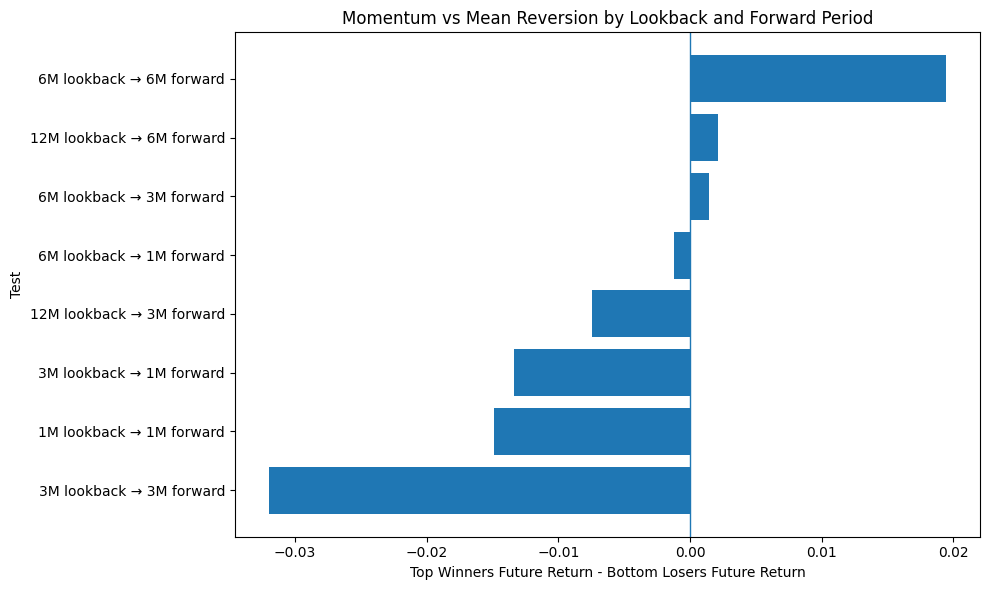

In [22]:
chart_df = comparison.copy()

chart_df["test_name"] = (
    chart_df["lookback_months"].astype(str)
    + "M lookback → "
    + chart_df["forward_months"].astype(str)
    + "M forward"
)

chart_df = chart_df.sort_values("winner_minus_loser_avg")

plt.figure(figsize=(10, 6))
plt.barh(chart_df["test_name"], chart_df["winner_minus_loser_avg"])
plt.axvline(0, linewidth=1)
plt.title("Momentum vs Mean Reversion by Lookback and Forward Period")
plt.xlabel("Top Winners Future Return - Bottom Losers Future Return")
plt.ylabel("Test")
plt.tight_layout()
plt.show()

In [23]:
comparison[
    [
        "lookback_months",
        "forward_months",
        "winner_minus_loser_avg",
        "winner_minus_loser_win_rate",
        "signal_label"
    ]
].sort_values("winner_minus_loser_avg", ascending=False)

,lookback_months,forward_months,winner_minus_loser_avg,winner_minus_loser_win_rate,signal_label
5,6,6,0.019445,0.082609,Momentum Favored
7,12,6,0.002144,0.008140,Momentum Favored
4,6,3,0.001422,0.035455,Momentum Favored
3,6,1,-0.001192,-0.019197,Mean Reversion Favored
6,12,3,-0.007460,0.017978,Mean Reversion Favored
1,3,1,-0.013362,-0.048288,Mean Reversion Favored
0,1,1,-0.014895,-0.086139,Mean Reversion Favored
2,3,3,-0.032007,-0.120251,Mean Reversion Favored


## Main Finding from Starter Universe

The comparison table suggests that the relationship between past and future relative performance depends on the time horizon.

Shorter-horizon tests show more evidence of mean reversion. In the 3-month lookback to 3-month forward test, past losers outperformed past winners by about 3.2 percentage points on average.

Longer-horizon tests show more evidence of momentum. The strongest continuation result appears in the 6-month lookback to 6-month forward test, where past winners outperformed past losers by about 1.9 percentage points on average.

The early conclusion is not that momentum always works or that mean reversion always works. Instead, the starter universe suggests a more nuanced pattern: short-term reversal and longer-term momentum.

This result needs to be tested on a larger universe before drawing stronger conclusions.